In [278]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shivamb/netflix-shows/netflix_titles.csv


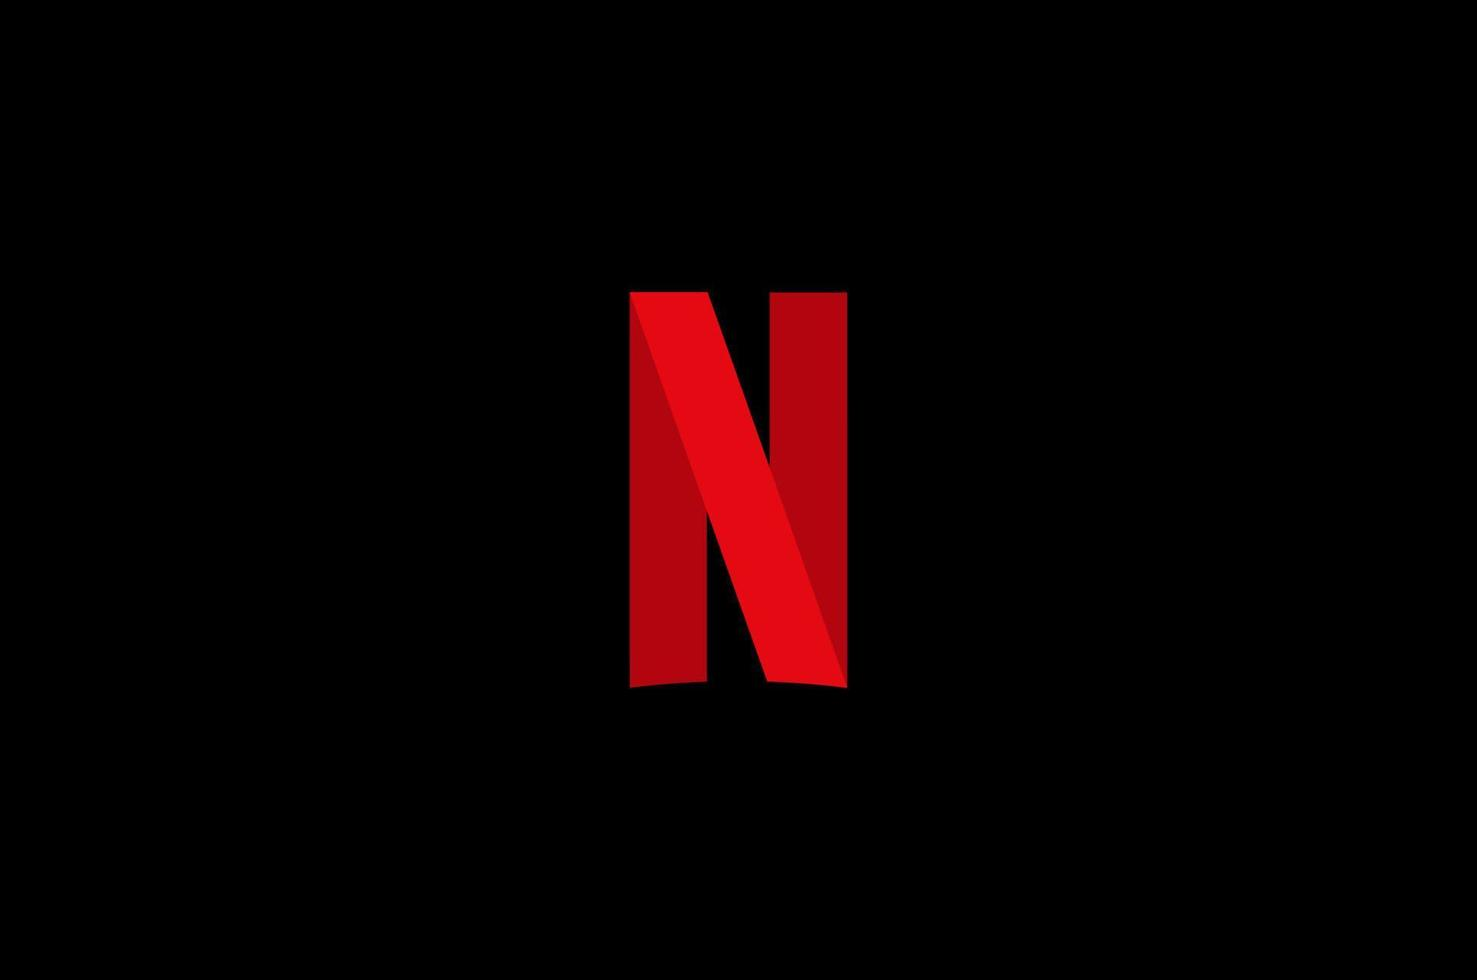 

# Netflix

## Overview
**Netflix** is one of the world's leading streaming entertainment platforms, offering a wide variety of movies, TV shows, documentaries, anime, and original content. Founded in **1997** by **Reed Hastings** and **Marc Randolph**, Netflix began as a DVD rental service before transforming into a global online streaming platform.

## Key Facts
- **Founded:** 1997
- **Headquarters:** Los Gatos, California, USA
- **Industry:** Entertainment and Streaming Media
- **Co-Founders:** Reed Hastings and Marc Randolph
- **CEO:** Ted Sarandos and Greg Peters (Co-CEOs)
- **Available In:** More than 190 countries
- **Website:** https://www.netflix.com

## Features
- Unlimited streaming of movies and TV shows.
- Personalized content recommendations based on viewing history.
- Availability across multiple devices, including smartphones, tablets, smart TVs, and computers.
- Offline downloads for selected content.
- Supports multiple user profiles and parental controls.

## Content Categories
- Movies
- TV Series
- Documentaries
- Kids & Family
- Anime
- Netflix Originals
- Reality Shows
- International Content

## Importance
- One of the largest streaming services in the world.
- Produces award-winning original content under the **Netflix Originals** brand.
- Uses data analytics and machine learning to recommend content to users.
- Plays a significant role in the global digital entertainment industry.

## Conclusion
Netflix has transformed the way people consume entertainment by making on-demand streaming accessible worldwide. Its extensive content library, personalized recommendations, and investment in original programming have made it one of the most popular streaming platforms globally.

In [279]:
#Calling our dataset 
df = pd.read_csv('/kaggle/input/datasets/shivamb/netflix-shows/netflix_titles.csv')

In [280]:
#Importing major libraries
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px 
import warnings
warnings.filterwarnings('ignore')

In [281]:
df.describe() #Describing our dataset 

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


### **Release Year Analysis**

- The `release_year` column contains **8,807** records.
- The **average release year** is **2014.18**, indicating that most titles are relatively recent.
- The **earliest release year** in the dataset is **1925**.
- The **latest release year** is **2021**.
- The **median (50th percentile)** release year is **2017**, meaning half of the titles were released in or after 2017.
- **25%** of the titles were released in **2013 or earlier**.
- **75%** of the titles were released in **2019 or earlier**.
- The **standard deviation** is **8.82 years**, suggesting a moderate variation in release years.
- Overall, the dataset is **heavily concentrated on content released between 2013 and 2021**.

In [282]:
df.info() #Seeking info 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


## Key Insights from `df.info()`

- The dataset contains **8,807 records** and **12 columns**, providing a comprehensive collection of Netflix titles.
- Most columns have the **object** data type, while **`release_year`** is the only **integer (`int64`)** column.
- Several columns contain **missing values**, particularly **`director`**, **`cast`**, **`country`**, **`date_added`**, **`rating`**, and **`duration`**, which may require data cleaning.
- The columns **`show_id`**, **`title`**, **`type`**, **`listed_in`**, and **`description`** have **no missing values**, indicating complete information for these features.
- The dataset uses approximately **825.8 KB of memory**, making it lightweight and efficient for data analysis and visualization.

In [283]:
# overview of the dataset 

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [284]:
df.shape

(8807, 12)

- **Dataset contains 8807 rows and 12 columns**

# 🎬 Netflix Dataset Columns

| **Column Name** | **Data Type** | **Description** |
|-----------------|---------------|-----------------|
| `show_id` | Object | Unique identifier assigned to each Netflix title. |
| `type` | Object | Specifies whether the content is a **Movie** or a **TV Show**. |
| `title` | Object | Name of the movie or TV show. |
| `director` | Object | Director(s) of the content. |
| `cast` | Object | Main actors and actresses featured in the content. |
| `country` | Object | Country where the content was produced. |
| `date_added` | Object | Date when the title was added to Netflix. |
| `release_year` | Integer | Original year in which the content was released. |
| `rating` | Object | Content maturity rating (e.g., TV-MA, PG-13, R). |
| `duration` | Object | Duration of a movie (in minutes) or number of seasons for a TV show. |
| `listed_in` | Object | Genre(s) or category of the content. |
| `description` | Object | Brief summary or synopsis of the content. |

In [285]:
#Duplicate Entries
df.duplicated().sum()

np.int64(0)

In [286]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


- So Dataset is free from **duplicacy issues** because np.int64(0)

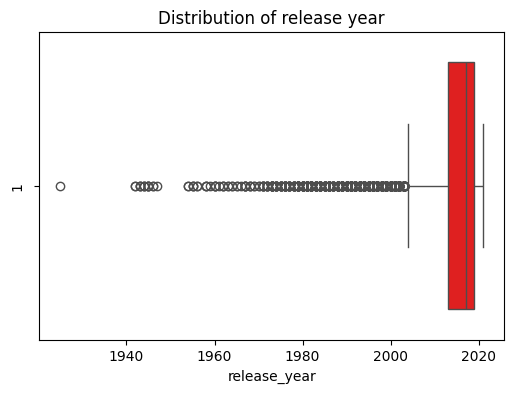

-----------------------------------------------------------------------------------------------------------------


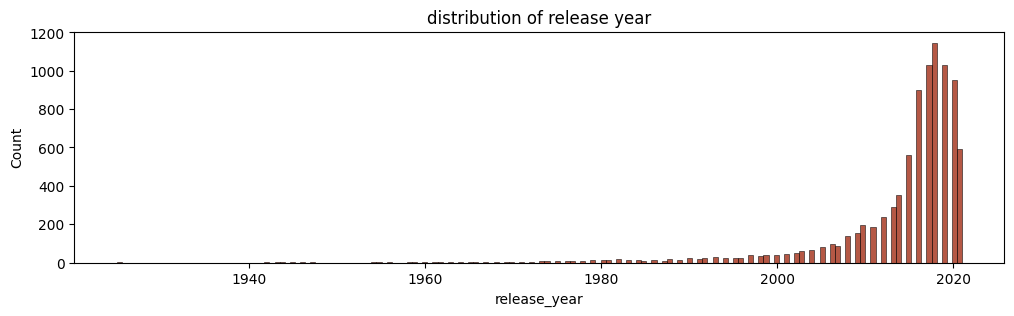

level of skewness	 -3.4465650403316013


In [287]:
#RELEASE YEAR
#Univariate Analysis --> (Univariate Analysis is the process of analyzing one variable)


#BOXPLOT
plt.figure(figsize=(6,4))
sns.boxplot(data=df,x='release_year',color = 'red')
plt.title('Distribution of release year')
plt.ylabel('1')
plt.show()

print('-'*113)
#HISTPLOT 
plt.figure(figsize=(12,3))
sns.histplot(data=df,x='release_year',color='#9C2007')
plt.title('distribution of release year')
plt.show()

print('level of skewness\t',df.release_year.skew())

### Insights from the Histplot (`release_year`)

- Most titles were released between **2015 and 2020**.
- The highest concentration of releases is around **2018–2019**.
- The number of titles increases rapidly after **2000**.
- Very few titles were released before **1980**.
- The distribution is **negatively (left) skewed**, indicating that the dataset mainly consists of recent releases with relatively few older titles.

### Insights from the Box Plot (`release_year`)

- Most release years are concentrated between **2013 and 2021**.
- Many older release years appear as **outliers**.
- The median release year is around **2017**, showing that half of the titles were released in or after 2017.
- The box plot confirms a **left-skewed (negative)** distribution.
- Overall, the dataset is dominated by **recently released content**.

In [288]:
q1 = df.release_year.quantile(0.25)
q2 = df.release_year.quantile(0.50)
q3 = df.release_year.quantile(0.75)
iqr = q3 - q1 

uf = q3 + 1.5 * iqr
lf = q1 - 1.5 * iqr 

print('Upper fence\t',uf)
print('Lower fence\t',lf)


Upper fence	 2028.0
Lower fence	 2004.0


### IQR Analysis (`release_year`)

- The **Interquartile Range (IQR)** is **6 years**, indicating that the middle 50% of titles were released within a 6-year period (2013–2019).
- The **Lower Fence** is **2004**, so titles released **before 2004** are considered potential outliers.
- The **Upper Fence** is **2028**, which is greater than the maximum release year (**2021**). Therefore, there are **no upper outliers** in the dataset.
- The dataset contains **only lower-end outliers**, representing older titles released before 2004.
- This confirms that the Netflix dataset is heavily concentrated on **recent content**, with only a small number of much older releases.

In [289]:
#Completeness related issues 
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

- The dataset contains missing values mainly in:
  - **director** → 2,634 missing values
  - **country** → 831 missing values
  - **cast** → 825 missing values
  - **date_added** → 10 missing values
  - **rating** → 4 missing values
  - **duration** → 3 missing values

In [290]:
#Percentage 
df.isnull().mean()*100

show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64

In [291]:
# GOLDEN RULE! 

# null values<5% --> mean,median and mode 
# null values>5% --> try to find some patterns / knn imputers
# null values>50% --> drop that column

In [292]:
df.rating.fillna(df.rating.mode().values[0],inplace=True)
df.date_added.fillna(df.date_added.mode().values[0],inplace=True)
df.country.fillna(df.country.mode().values[0],inplace=True)

In [293]:
df.isnull().sum()[df.isnull().sum()>0]


director    2634
cast         825
duration       3
dtype: int64

In [294]:
df.director.fillna('unknown',inplace=True)
df.cast.fillna('unknown',inplace=True)

In [295]:
df.isnull().sum()[df.isnull().sum()>0]

duration    3
dtype: int64

### Exploratory Data Analysis

In [296]:
num = list(df.describe().columns)

cat = []

for i in df.columns:
    if i not in num:
        cat.append(i)

print('Categorical columns\t',cat)
print(110*'-')
print('Numerical columns\t',num)

Categorical columns	 ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'rating', 'duration', 'listed_in', 'description']
--------------------------------------------------------------------------------------------------------------
Numerical columns	 ['release_year']


In [297]:
#Pie chart of type

temp_type = df.type.value_counts().reset_index()

temp_type

fig = px.pie(temp_type,names='type',values='count',hole=0.5,
             title='Distribution of Movies and TV Shows on Netflix',color='type',
             color_discrete_map = {'Movie': '#E50914',     # Netflix Red
        'TV Show': '#1F77B4'    # Blue
                                   }) 

# Layout Improvements
fig.update_traces(
    textinfo='percent+label',
    pull=[0.03, 0.03],
    marker=dict(line=dict(color='white', width=2))
)

fig.update_layout(
    title_x=0.5,
    template='plotly_white',
    font=dict(size=14),
    legend_title='Content Type'
)

# fig.show()
fig.show()

- Movies contribute nearly 69% of the total Netflix content library, while TV Shows account for approximately 31%.

- This indicates that Netflix primarily focuses on movie-based entertainment, with movies dominating the platform’s overall catalog.

- Comparatively, the number of TV Shows is significantly lower, suggesting that Netflix contains a much larger collection of films than episodic content.

In [298]:
temp_director = df.director.value_counts().sort_values(ascending=False).drop('unknown').head(10).reset_index()

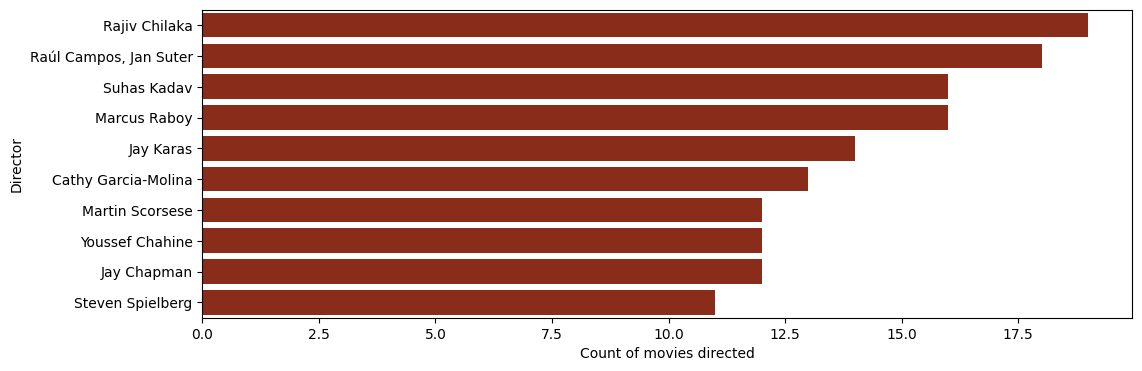

In [299]:
plt.figure(figsize=(12,4))
sns.barplot(data=temp_director,x='count',y='director',color='#9C2007')
plt.xlabel('Count of movies directed')
plt.ylabel('Director')
plt.show()

In [300]:
temp_director
df[df.director=='Raúl Campos, Jan Suter']
df[df.director=='Marcus Raboy']
df[df.director=='David Dhawan']

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
205,s206,Movie,Kyo Kii... Main Jhuth Nahin Bolta,David Dhawan,"Govinda, Sushmita Sen, Rambha, Anupam Kher, Sa...",India,"August 27, 2021",2001,TV-14,150 min,"Comedies, International Movies, Sci-Fi & Fantasy",The life and career of a lawyer are thrown int...
2270,s2271,Movie,Chashme Baddoor,David Dhawan,"Rishi Kapoor, Ali Zafar, Taapsee Pannu, Siddha...",India,"July 5, 2020",2013,TV-14,121 min,"Comedies, International Movies, Music & Musicals",When pretty new neighbor Seema falls for their...
5009,s5010,Movie,Judwaa 2,David Dhawan,"Varun Dhawan, Jacqueline Fernandez, Tapsee Pan...",India,"March 1, 2018",2017,TV-14,145 min,"Action & Adventure, Comedies, International Mo...","Separated at birth, twins Raja and Prem couldn..."
6440,s6441,Movie,Chal Mere Bhai,David Dhawan,"Sanjay Dutt, Salman Khan, Karisma Kapoor, Dali...",India,"December 31, 2019",2000,TV-14,132 min,"Comedies, International Movies, Romantic Movies","When a secretary saves her tycoon boss's life,..."
6449,s6450,Movie,Chashme Buddoor,David Dhawan,"Ali Zafar, Siddharth, Divyendu Sharma, Tapsee ...",India,"May 1, 2017",2013,TV-PG,121 min,"Comedies, International Movies, Music & Musicals",When pretty new neighbor Seema falls for their...
6936,s6937,Movie,Haseena Maan Jaayegi,David Dhawan,"Sanjay Dutt, Govinda, Karisma Kapoor, Pooja Ba...",India,"March 1, 2018",1999,TV-PG,151 min,"Action & Adventure, Comedies, Dramas",A millionaire opens the door to comic complica...
7144,s7145,Movie,Judwaa,David Dhawan,"Salman Khan, Karisma Kapoor, Rambha, Kader Kha...",India,"December 31, 2019",1997,TV-14,133 min,"Comedies, International Movies, Romantic Movies","Separated at birth, a pair of identical twins ..."
7386,s7387,Movie,Maine Pyaar Kyun Kiya,David Dhawan,"Salman Khan, Sushmita Sen, Sohail Khan, Katrin...",India,"December 31, 2019",2005,TV-14,137 min,"Comedies, International Movies, Music & Musicals","After lying to his girlfriend, orthopedic surg..."
7524,s7525,Movie,Mujhse Shaadi Karogi,David Dhawan,"Rajpal Yadav, Amrish Puri, Kader Khan, Shashi ...",India,"December 31, 2019",2004,TV-PG,158 min,"Comedies, International Movies, Romantic Movies","Samir must overcome a hostile horoscope, a hot..."


In [301]:
df.cast.str.split(',',expand=True)


,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,unknown,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
1,Ama Qamata,Khosi Ngema,Gail Mabalane,Thabang Molaba,Dillon Windvogel,Natasha Thahane,Arno Greeff,Xolile Tshabalala,Getmore Sithole,Cindy Mahlangu,...,None,None,None,None,None,None,None,None,None,None
2,Sami Bouajila,Tracy Gotoas,Samuel Jouy,Nabiha Akkari,Sofia Lesaffre,Salim Kechiouche,Noureddine Farihi,Geert Van Rampelberg,Bakary Diombera,None,...,None,None,None,None,None,None,None,None,None,None
3,unknown,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
4,Mayur More,Jitendra Kumar,Ranjan Raj,Alam Khan,Ahsaas Channa,Revathi Pillai,Urvi Singh,Arun Kumar,None,None,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,Mark Ruffalo,Jake Gyllenhaal,Robert Downey Jr.,Anthony Edwards,Brian Cox,Elias Koteas,Donal Logue,John Carroll Lynch,Dermot Mulroney,Chloë Sevigny,...,None,None,None,None,None,None,None,None,None,None
8803,unknown,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
8804,Jesse Eisenberg,Woody Harrelson,Emma Stone,Abigail Breslin,Amber Heard,Bill Murray,Derek Graf,None,None,None,...,None,None,None,None,None,None,None,None,None,None
8805,Tim Allen,Courteney Cox,Chevy Chase,Kate Mara,Ryan Newman,Michael Cassidy,Spencer Breslin,Rip Torn,Kevin Zegers,None,...,None,None,None,None,None,None,None,None,None,None


In [302]:
df.cast.str.split(',',expand=True).iloc[:,0:2]


,0,1
0,unknown,None
1,Ama Qamata,Khosi Ngema
2,Sami Bouajila,Tracy Gotoas
3,unknown,None
4,Mayur More,Jitendra Kumar
...,...,...
8802,Mark Ruffalo,Jake Gyllenhaal
8803,unknown,None
8804,Jesse Eisenberg,Woody Harrelson
8805,Tim Allen,Courteney Cox


In [303]:
temp_lead = df.cast.str.split(',',expand=True)[0].value_counts().drop('unknown').head(15).reset_index().rename({
    0:'lead_actor','count':'no_movies'},axis=1)

In [304]:
temp_second_lead = df.cast.str.split(',',expand=True)[1].value_counts().head(10).reset_index().rename({
    1:'secondary_lead','count':'no_movies'},axis=1)

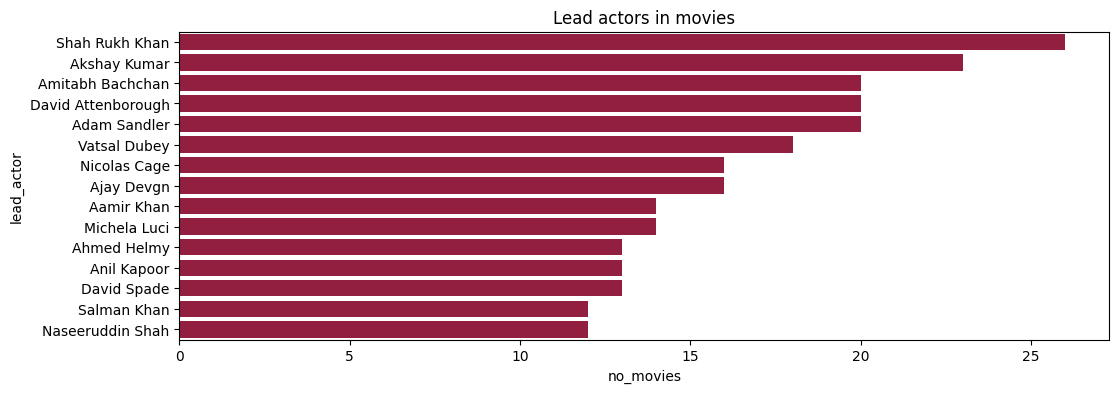

In [305]:
# Barchart on primary lead 

plt.figure(figsize=(12,4))
sns.barplot(data=temp_lead, y= 'lead_actor',x='no_movies',color='#A50C36')
plt.title('Lead actors in movies')
plt.show()

### Insights from Lead Actors in Movies

- **Shah Rukh Khan** has the highest number of movie appearances (**26**), making him the most frequent lead actor in the dataset.
- **Akshay Kumar** ranks second with **23** lead roles.
- **Amitabh Bachchan**, **David Attenborough**, and **Adam Sandler** each appear in **20** movies.
- The list includes actors from **different film industries**, including Bollywood and Hollywood.
- Most of the top lead actors have appeared in **12–26 movies** on Netflix.
- The chart highlights the actors who have the **largest presence in Netflix's movie collection**.

In [306]:
print('cat ',cat)
print('num ',num)

cat  ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'rating', 'duration', 'listed_in', 'description']
num  ['release_year']


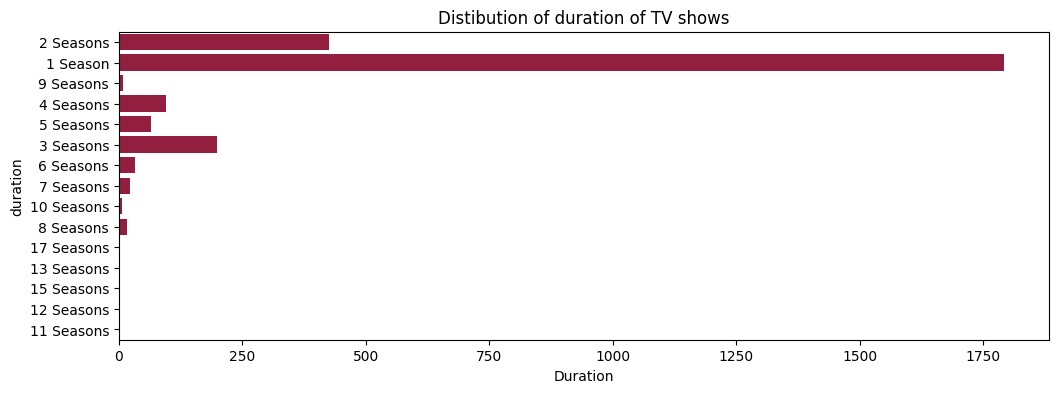

In [307]:
# Duration 

tv_show = df[df.type=='TV Show']

tv_show

plt.figure(figsize=(12,4))
sns.countplot(data=tv_show,y='duration',color='#A50C36')
plt.xlabel('Duration')
plt.title('Distibution of duration of TV shows')
plt.show()

### Insights from the Distribution of TV Show Duration

- Most TV shows on Netflix have **only 1 season**.
- The number of TV shows decreases as the number of seasons increases.
- Shows with **2–3 seasons** are fairly common but much fewer than single-season shows.
- TV shows with **more than 5 seasons** are relatively rare.
- Very few shows have **10 or more seasons**.
- The distribution indicates that Netflix's catalog is dominated by **short-running TV shows**.

In [308]:
Movie = df[df['type'] == 'Movie'].copy()

Movie['duration'] = (
    Movie['duration']
    .astype(str)
    .str.extract(r'(\d+)')[0]
)

Movie['duration'] = pd.to_numeric(Movie['duration'], errors='coerce')
Movie = Movie.dropna(subset=['duration'])
Movie['duration'] = Movie['duration'].astype(int)

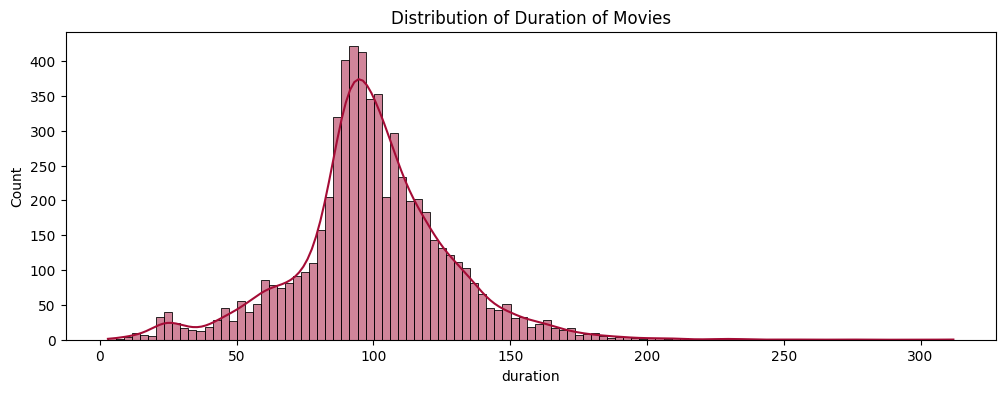

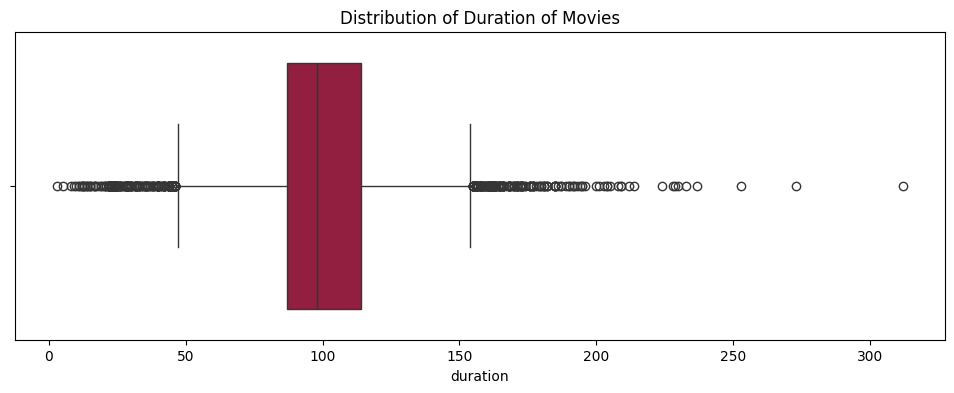

Skewness: 0.2025791123063926


In [309]:
plt.figure(figsize=(12,4))
sns.histplot(data=Movie, x='duration', color='#A50C36', kde=True)
plt.title('Distribution of Duration of Movies')
plt.show()

plt.figure(figsize=(12,4))
sns.boxplot(data=Movie, x='duration', color='#A50C36')
plt.title('Distribution of Duration of Movies')
plt.show()

print("Skewness:", Movie['duration'].skew())

### Insights from the Histplot (`duration`)

- Most movies have a duration between **80 and 120 minutes**.
- The highest concentration of movies is around **90–100 minutes**.
- Very short (<50 min) and very long (>180 min) movies are uncommon.
- The distribution is **slightly right-skewed**, with a few movies having much longer durations.

### Insights from the Box Plot (`duration`)

- The median movie duration is around **100 minutes**.
- Most movie durations lie between **85 and 115 minutes**.
- There are outliers on both the lower and upper ends.
- More outliers are present on the **higher duration** side, representing unusually long movies.
- The box plot confirms a **slight positive (right) skew** in movie durations.

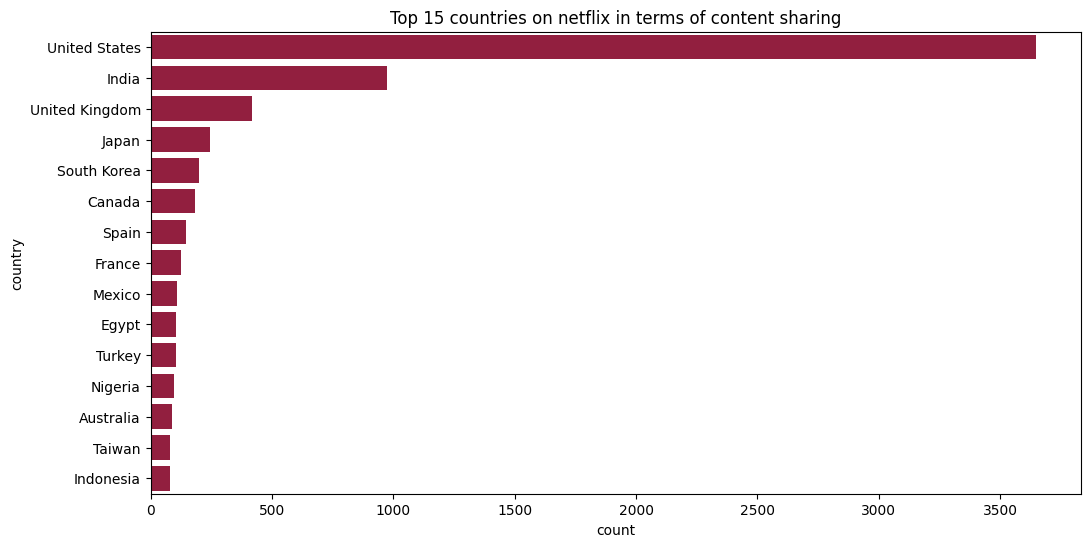

In [310]:
temp_country = df.country.value_counts().reset_index().head(15)
plt.figure(figsize=(12,6))
sns.barplot(data=temp_country,y='country',x='count',color='#A50C36')
plt.title('Top 15 countries on netflix in terms of content sharing')
plt.show()

### Insights from Top 15 Countries by Netflix Content

- The **United States** contributes the highest number of titles on Netflix by a large margin.
- **India** ranks second, followed by the **United Kingdom**.
- **Japan** and **South Korea** are among the top Asian content contributors.
- The remaining countries contribute significantly fewer titles compared to the top three.
- The chart shows that Netflix's content library is **dominated by a few major countries**, particularly the United States.

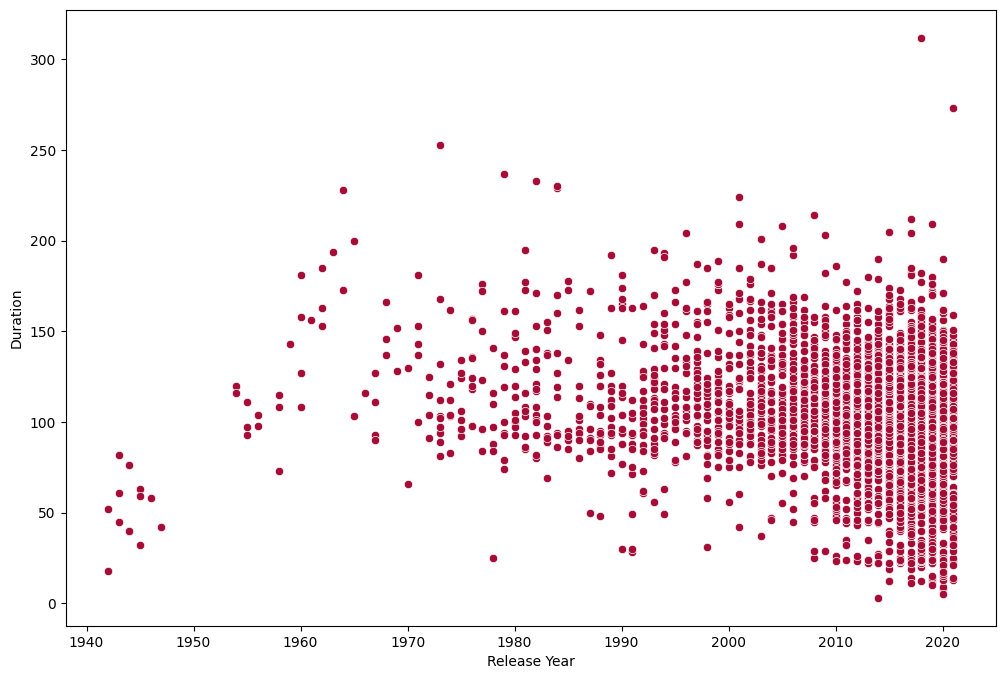

--------------------------------------------------------------------------------------------------------------


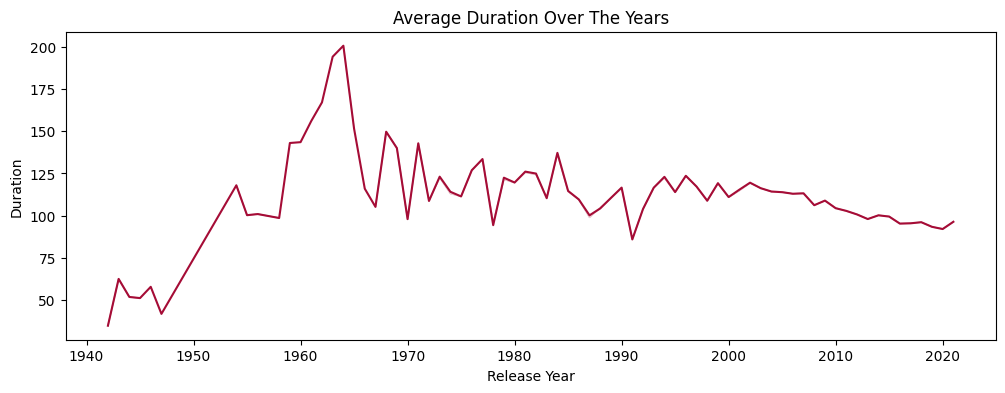

In [311]:
 #Trend Graph between release-year and duration 
plt.figure(figsize=(12,8))
sns.scatterplot(data=Movie,x='release_year',y='duration',color='#A50C36')
plt.xlabel('Release Year')
plt.ylabel('Duration')
plt.show()

print('-'*110)

plt.figure(figsize=(12,4)) 
sns.lineplot(data=Movie,x='release_year',y='duration',ci=False,color='#A50C36')
plt.title('Average Duration Over The Years')
plt.xlabel('Release Year')
plt.ylabel('Duration')
plt.show()

### Insights from the Scatter Plot (`release_year` vs `duration`)

- Most movies released after **2000** have durations between **80 and 120 minutes**.
- There is **no strong relationship** between release year and movie duration.
- A few movies have unusually long durations (**over 200 minutes**), which appear as outliers.
- The majority of movie durations remain within a similar range across different release years.
- The number of movies released increases significantly in recent years.

### Insights from the Line Plot (Average Duration Over the Years)

- The average movie duration fluctuates across different release years.
- Earlier years show greater variation due to a smaller number of movies.
- From the **1980s onwards**, the average duration remains fairly stable.
- In recent years, the average movie duration is around **95–110 minutes**.
- Overall, there is **no significant long-term increase or decrease** in average movie duration.

In [312]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,unknown,unknown,United States,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,unknown,unknown,United States,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [313]:
df['rating'].value_counts(dropna=False)

rating
TV-MA       3211
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

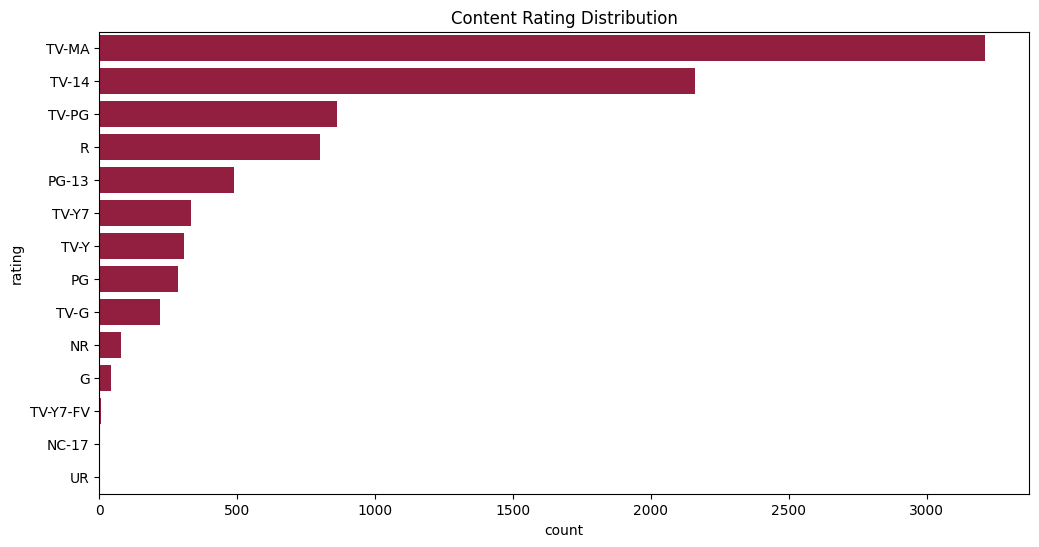

In [314]:
#Rating 
plt.figure(figsize=(12,6))
sns.countplot(data=dt,y='rating',order=dt['rating'].value_counts().index,color='#A50C36')
plt.title('Content Rating Distribution')
plt.show()

## Short Understanding of Netflix Content Ratings

- **TV-MA** → Content for **adults (18+)**. May include strong violence, explicit language, or mature themes.
- **TV-14** → Suitable for **viewers aged 14 and above**. May contain moderate violence, language, or mature content.
- **TV-PG** → **Parental guidance suggested**. Suitable for teenagers and families with supervision.
- **R** → **Restricted**. Viewers under 17 should watch with a parent or guardian.
- **PG-13** → Parents are **strongly cautioned**. Some content may be inappropriate for children under 13.
- **TV-Y7** → Designed for **children aged 7 and above**.
- **TV-Y** → Suitable for **all young children**.
- **PG** → Family-friendly content. Parental guidance is recommended.
- **TV-G** → Suitable for **general audiences** of all ages.
- **G** → Suitable for **everyone**, including children.
- **NR** → **Not Rated**. No official age rating has been assigned.
- **TV-Y7-FV** → Suitable for children **7+** and may contain **fantasy violence**.
- **NC-17** → **Adults only (17+)**. Not suitable for children.
- **UR** → **Unrated**. The content has not received an official rating.


### Insights from the Content Rating Distribution

- **TV-MA** is the most common content rating on Netflix, indicating a large amount of content intended for mature audiences.
- **TV-14** is the second most frequent rating, followed by **TV-PG**.
- Movie ratings such as **R** and **PG-13** also have a significant presence.
- Family-friendly ratings like **TV-Y**, **TV-G**, and **G** are less common.
- Ratings such as **TV-Y7-FV**, **NC-17**, and **UR** have very few titles.
- Overall, Netflix's catalog is primarily focused on **teen and adult audiences**.

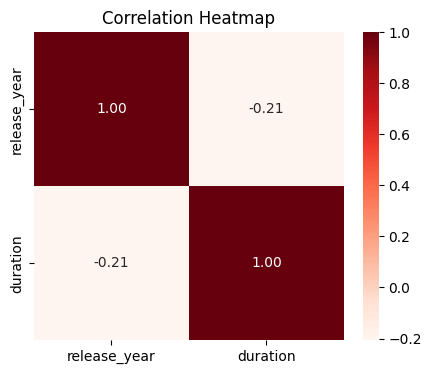

In [315]:
#corr map 

corr = Movie[['release_year', 'duration']].corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap='Reds', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

### Insights from the Correlation Heatmap

- The correlation between **`release_year`** and **`duration`** is **-0.21**.
- This indicates a **weak negative correlation** between the two variables.
- As the release year increases, movie duration tends to decrease **slightly**, but the relationship is not strong.
- The correlation value is close to **0**, suggesting that **release year has little influence on movie duration**.
- Overall, there is **no significant linear relationship** between release year and duration.

# 📊 Netflix Exploratory Data Analysis (EDA) Report

## 📌 Summary

- This EDA explores the Netflix dataset to understand content trends, audience preferences, genre distribution, duration patterns, content ratings, and country-wise contributions.
- Netflix's catalog is primarily dominated by **Movies (≈69%)**, while **TV Shows contribute ≈31%**.
- The platform focuses heavily on **movie-based entertainment** compared to episodic content.
- Indian entertainment has a strong presence, with **Shah Rukh Khan** and **Akshay Kumar** among the most frequently appearing actors.
- Most TV Shows have **only one season**, indicating Netflix mainly promotes short-format or limited-series content.
- Movie durations are mostly between **50–150 minutes**, with only a few exceptionally long movies.
- Average movie duration increased during the **1960s**, then gradually stabilized around **100–120 minutes**, with a slight decline in recent years.
- The **United States** contributes the largest amount of content, followed by **India**.
- Countries such as **Japan** and **South Korea** also contribute significantly through anime and drama content.
- **TV-MA** and **TV-14** are the most common content ratings, showing Netflix mainly targets mature and young-adult audiences.
- **Drama, Comedy, and Documentaries** are among the most common genres on the platform.
- Correlation analysis shows a **weak negative relationship (-0.24)** between release year and movie duration, indicating movies have become slightly shorter over time.

---

# ✅ Conclusion

- Netflix is primarily a **movie-focused streaming platform**.
- Most TV Shows are **short-running**, usually with only one season.
- The platform mainly targets **adult and young-adult viewers**, as shown by the dominance of TV-MA and TV-14 ratings.
- The **United States** remains the largest contributor, while **India** has become one of Netflix's fastest-growing content markets.
- International content from countries like **Japan** and **South Korea** has strengthened Netflix's global reach.
- Movie durations have gradually become shorter, reflecting changing audience viewing habits.
- Netflix's success is driven by a combination of **global content diversity**, **regional entertainment industries**, and **audience-focused storytelling**.

---

# ⚠️ Advisories

- The analysis is based only on the available Netflix dataset and may not represent Netflix's complete catalog.
- Some records contain **missing or inconsistent values**, which may slightly affect the results.
- Correlation indicates **association, not causation**.
- Netflix content varies across countries, so results may differ by region.
- Actor appearance counts represent **frequency in the dataset**, not popularity.
- Genre and rating distributions may change as Netflix updates its catalog.
- This is an **exploratory analysis** and does not include predictive modeling or machine learning.
- A few extreme values (outliers) may influence statistical summaries and visualizations.
- International content trends depend on both Netflix's expansion and dataset coverage.
- This report is intended for **educational and analytical purposes** only.